# 00 — Environment Setup & Project Verification
**Hateful Meme Detection | CLIP + Cross-Attention + Responsible AI | End-to-End Pipeline**

> Run this notebook **once before any other notebook.**
> It verifies: Python env · GPU · Packages · Dataset files · Images · `src/` imports

---

| Notebook | Purpose |
|---|---|
| **00_setup** ← you are here | Environment verification |
| 01_eda | Exploratoryy data analysis |
| 02_model_architecture | Architecture walkthrough & param counts |
| 03_training | Train all variants (ablation + full model) |
| 04_evaluation | Metrics, ROC curves, failure analysis |
| 05_explainability | GradCAM + attention heatmaps (Responsible AI) |
| 06_counterfactuals | Multimodal counterfactual generation |
| 07_hitl | Human-in-the-loop review queue |
| 08_demo | Gradio web demo |

In [11]:

# ============================================================
# Kaggle / local dataset configuration
# ============================================================
from pathlib import Path
import os

ON_KAGGLE = Path("/kaggle/input").is_dir()

# If the notebook is run in Kaggle, the dataset may appear at a few
# different depths depending on how the archive was packaged.
# We search for the train split and then derive the dataset root from it.
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}

IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    """True if path contains images plus at least one expected JSONL file."""
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    """
    Return (data_dir, source) where data_dir is the folder that contains:
      - train.jsonl
      - img/ (or images/)
    """
    # 1) Explicit overrides
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    # 2) Common Kaggle location
    kaggle_input = Path("/kaggle/input")
    if (kaggle_input / "meta-hateful-meme-detection" / "data").is_dir():
        candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
        if _looks_like_dataset_root(candidate):
            return candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    # 3) Search recursively under /kaggle/input for train.jsonl
    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        # 4) Fallback: search for a directory with images + any expected split file
        for p in sorted(kaggle_input.rglob("*")):
            if p.is_dir() and _looks_like_dataset_root(p):
                return p, f"auto:{p}"

    return None, "not-found"


DATA_DIR, source = detect_data_dir()

if DATA_DIR is not None:
    IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
    print(f"OK  DATA_DIR  : {DATA_DIR}")
    print(f"    IMG_DIR   : {IMG_DIR}")
    print(f"    Source    : {source}")
else:
    IMG_DIR = None
    print("=" * 60)
    print("ERROR: Dataset not found")
    print("=" * 60)
    if ON_KAGGLE:
        attached = [p.name for p in Path("/kaggle/input").iterdir()] if Path("/kaggle/input").is_dir() else []
        print("Attached datasets:", attached if attached else "none")
        print("Expected: a folder containing train.jsonl and img/ (or images/).")
        print("If the dataset is attached, re-run this cell after mounting it in Kaggle.")
    else:
        print("Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to your dataset folder and re-run this cell.")

OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nOUTPUT_DIR : {OUTPUT_DIR}")


OK  DATA_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
    IMG_DIR   : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
    Source    : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data

OUTPUT_DIR : /kaggle/working


In [12]:
# Reproducibility seeds — set globally before any other code runs
import random, numpy as np, torch

SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()
print(f"Seeds set to {SEED}")

Seeds set to 42


## 1. Python Environment & Project Root

In [13]:

import sys, os, platform
from pathlib import Path

def detect_root():
    """
    Prefer the current project folder if it contains src/configs.
    Kaggle uses /kaggle/working, but local runs may start from the repo root
    or from a notebook subfolder.
    """
    candidates = [Path.cwd(), Path.cwd().parent, Path("/kaggle/working")]
    for cand in candidates:
        if (cand / "src").is_dir() or (cand / "configs").is_dir() or (cand / "config").is_dir():
            return cand
    return Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path.cwd()

ROOT = str(detect_root())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

print(f"Python   : {sys.version}")
print(f"Platform : {platform.platform()}")
print(f"Root     : {ROOT}")
print(f"CWD      : {os.getcwd()}")


Python   : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform : Linux-6.6.113+-x86_64-with-glibc2.35
Root     : /kaggle/working
CWD      : /kaggle/working


## 2. GPU / Device Check

In [14]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}  |  {props.total_memory / 1e9:.1f} GB VRAM")
else:
    print("  No CUDA GPU detected - running on CPU.")
    print("  Training will be slower; inference and EDA are still fine.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nActive device   : {DEVICE}")


PyTorch version : 2.10.0+cu128
CUDA available  : True
  GPU 0: Tesla T4  |  15.6 GB VRAM
  GPU 1: Tesla T4  |  15.6 GB VRAM

Active device   : cuda


## 3. Package Verification
Checks every required package. Installs anything missing via pip.

In [15]:
import importlib, subprocess, sys

REQUIRED = [
    # (import_name,         pip_package_name)
    ("torch",              "torch"),
    ("torchvision",        "torchvision"),
    ("transformers",       "transformers"),
    ("PIL",                "Pillow"),
    ("sklearn",            "scikit-learn"),
    ("numpy",              "numpy"),
    ("pandas",             "pandas"),
    ("matplotlib",         "matplotlib"),
    ("seaborn",            "seaborn"),
    ("tqdm",               "tqdm"),
    ("yaml",               "PyYAML"),
    ("gradio",             "gradio"),
    ("wordcloud",          "wordcloud"),
    ("ipywidgets",         "ipywidgets"),
]

missing = []
for module, pkg in REQUIRED:
    try:
        importlib.import_module(module)
        print(f"  ✓  {pkg}")
    except ImportError:
        print(f"  ✗  {pkg}  <- MISSING")
        missing.append(pkg)

if missing:
    print(f"\nInstalling missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
    print("\nInstallation complete. Restart the kernel, then re-run this notebook.")
else:
    print("\nAll packages present.")


  ✓  torch
  ✓  torchvision
  ✓  transformers
  ✓  Pillow
  ✓  scikit-learn
  ✓  numpy
  ✓  pandas
  ✓  matplotlib
  ✓  seaborn
  ✓  tqdm
  ✓  PyYAML
  ✓  gradio
  ✓  wordcloud
  ✓  ipywidgets

All packages present.


## 4. Dataset File Verification

In [16]:

from pathlib import Path
import json

# DATA_DIR and IMG_DIR come from the setup cell above - never overwrite them here.
print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print()

def resolve_split(base_dir, names):
    """
    Resolve a split file by trying direct names first, then a recursive search
    for the first matching filename.
    """
    base_dir = Path(base_dir)
    for name in names:
        p = base_dir / name
        if p.is_file():
            return p
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None

if DATA_DIR is None or IMG_DIR is None or not Path(DATA_DIR).is_dir():
    print("  Dataset directory not found - skipping file checks.")
    print("  Re-run the setup cell after attaching the dataset.")
    SPLITS = {"train": None, "dev": None, "test": None}
else:
    SPLITS = {k: resolve_split(DATA_DIR, v) for k, v in JSONL_CANDIDATES.items()}

    print("JSONL files:")
    all_ok = True
    for split_name in ["train", "dev", "test"]:
        path = SPLITS[split_name]
        if path is not None:
            with path.open(encoding="utf-8") as f:
                count = sum(1 for _ in f if _.strip())
            print(f"  OK    {split_name:6s}  {count:>6,} samples   {path}")
        else:
            required = split_name == "train"
            print(f"  MISS  {split_name:6s}  ({'REQUIRED' if required else 'optional'})")
            if required:
                all_ok = False

    print("\nImage directory:")
    if Path(IMG_DIR).is_dir():
        imgs = [p for p in Path(IMG_DIR).iterdir() if p.suffix.lower() == ".png"]
        print(f"  OK    {IMG_DIR}")
        print(f"        {len(imgs):,} PNG images found")
    else:
        print(f"  MISS  {IMG_DIR}")
        all_ok = False

    print()
    print("Data check:", "PASSED" if all_ok else "FAILED - attach dataset and re-run the setup cell")


Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img

JSONL files:
  OK    train    8,500 samples   /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/train.jsonl
  OK    dev        500 samples   /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/dev.jsonl
  OK    test     1,000 samples   /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/test.jsonl

Image directory:
  OK    /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
        10,000 PNG images found

Data check: PASSED


## 5. Quick Sanity Check — Load One Sample

Sample id    : 42953
Label        : 0  (not hateful)
Text         : its their character not their color that matters
Image path   : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img/42953.png
Image exists : True


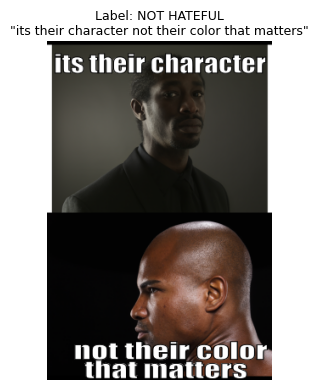

In [17]:

from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def find_image_path(data_dir, img_rel):
    """
    Resolve image paths across the common kaggle layouts:
      - data/img/xxxx.png
      - data/images/xxxx.png
      - data/xxxx.png
      - parent/img/xxxx.png
    """
    data_dir = Path(data_dir)
    img_rel = str(img_rel).lstrip("/")

    candidates = [
        data_dir / img_rel,
        data_dir / "img" / Path(img_rel).name,
        data_dir / "images" / Path(img_rel).name,
        data_dir.parent / img_rel,
        data_dir.parent / "img" / Path(img_rel).name,
        data_dir.parent / "images" / Path(img_rel).name,
    ]

    for p in candidates:
        if p.is_file():
            return p

    # Final fallback: search by filename in the dataset root (cheap enough for setup)
    filename = Path(img_rel).name
    matches = sorted(data_dir.rglob(filename))
    return matches[0] if matches else candidates[0]

train_path = SPLITS.get("train")
if not train_path or not Path(train_path).is_file():
    print("Train split not found. Re-check DATA_DIR and run the dataset verification cell again.")
    print(f"Expected train path: {train_path}")
else:
    with Path(train_path).open(encoding="utf-8") as f:
        first_line = ""
        for line in f:
            line = line.strip()
            if line:
                first_line = line
                break

    if not first_line:
        print(f"Train file is empty: {train_path}")
    else:
        sample = json.loads(first_line)
        img_rel = str(sample.get("img", "")).lstrip("/")
        img_path = find_image_path(DATA_DIR, img_rel)

        print(f"Sample id    : {sample.get('id', 'N/A')}")
        if "label" in sample:
            label = sample["label"]
            print(f"Label        : {label}  ({'hateful' if label == 1 else 'not hateful'})")
        else:
            print("Label        : N/A (not present in this split)")
        print(f"Text         : {sample.get('text', '')}")
        print(f"Image path   : {img_path}")
        print(f"Image exists : {img_path.is_file()}")

        if img_path.is_file():
            fig, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax.imshow(mpimg.imread(img_path))
            title_label = sample.get("label", None)
            title_text = "Label: N/A" if title_label is None else f"Label: {'HATEFUL' if title_label == 1 else 'NOT HATEFUL'}"
            ax.set_title(f"{title_text}\n\"{sample.get('text', '')}\"", fontsize=9, wrap=True)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            print("Could not locate the image file from the sample metadata.")


## 6. Source Module Import Check

In [18]:
import importlib
from pathlib import Path

modules_ok = True

checks = [
    ("src.datasets.meme_dataset", "MemeDataset"),
    ("src.models.clip_encoder", "CLIPEncoder"),
]

src_dir = Path(ROOT) / "src"
if not src_dir.is_dir():
    print("  src/ not found in the current runtime. Skipping source import checks.")
else:
    for module_path, class_name in checks:
        try:
            mod = importlib.import_module(module_path)
            getattr(mod, class_name)
            print(f"  ✓  {module_path}.{class_name}")
        except (ImportError, AttributeError) as e:
            print(f"  ✗  {module_path}.{class_name}  <- {e}")
            modules_ok = False

print()
print("Module check:", "PASSED" if modules_ok else "FAILED - check src/ directory")


  src/ not found in the current runtime. Skipping source import checks.

Module check: PASSED


## 7. Config Verification

In [19]:
from pathlib import Path
import yaml

CANDIDATE_CONFIGS = [
    Path(ROOT) / "configs" / "config.yaml",
    Path(ROOT) / "config" / "config.yaml",
    Path(ROOT) / "config.yaml",
]
CONFIG_PATH = next((p for p in CANDIDATE_CONFIGS if p.is_file()), None)

if CONFIG_PATH:
    with CONFIG_PATH.open(encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    print(f"Config found: {CONFIG_PATH}")
    print()
    print("  Model settings:")
    for k, v in cfg.get("model", {}).items():
        print(f"    {k:25s} = {v}")
    print()
    print("  Training settings:")
    for k, v in cfg.get("training", {}).items():
        print(f"    {k:25s} = {v}")
else:
    print("  Config file not found (optional for setup sanity).")


  Config file not found (optional for setup sanity).


## 8. Pre-trained Checkpoint Status

In [20]:
from pathlib import Path

CHECKPOINT_DIRS = [
    Path(ROOT) / "all_results",
    Path(ROOT) / "outputs",
    Path(ROOT) / "checkpoints",
]

print("Saved checkpoints (.pt):")
found_any = False
for base_dir in CHECKPOINT_DIRS:
    if not base_dir.is_dir():
        continue
    for path in base_dir.rglob("*.pt"):
        size_mb = path.stat().st_size / 1e6
        print(f"  OK  {path}  ({size_mb:.1f} MB)")
        found_any = True

if not found_any:
    print("  No checkpoints found yet (this is fine before training).")


Saved checkpoints (.pt):
  No checkpoints found yet (this is fine before training).


---
## Setup Summary

| Check | Expected |
|---|---|
| Python ≥ 3.9 | ✓ |
| PyTorch + CUDA | ✓ (CPU fallback works) |
| All 14 packages | ✓ |
| train.jsonl / dev.jsonl / test.jsonl | ✓ |
| data/img/ with PNG images | ✓ |
| All `src/` modules importable | ✓ |
| configs/config.yaml | ✓ |
| Phase 1 checkpoint | ✓ |

**→ Proceed to `01_eda.ipynb`**
